In [1]:
import pandas as pd
import os
os.chdir('../..')
os.getcwd()



'/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency'

In [2]:
highLow = pd.read_csv('output/splitDecay/high/train_ame_output/ame.tsv',sep='\t')
llm = pd.read_csv('output/motifs/positive/ame_output/ame.tsv', sep='\t')


In [3]:

highLow = highLow[~highLow[['motif_alt_ID']].duplicated()]
llm = llm[~llm[['motif_alt_ID']].duplicated()]

In [4]:
highLow

,rank,motif_DB,motif_ID,motif_alt_ID,consensus,p-value,adj_p-value,E-value,tests,FASTA_max,pos,neg,PWM_min,TP,%TP,FP,%FP
0,1,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00142,QKR58E-1,AUAAUAA,0.000012,0.0136,0.407,1143.0,1696.0,1696.0,1698.0,3.80,52.0,3.07,17.0,1.00
1,2,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00120,FNE,UUUDGUU,0.000010,0.0221,0.663,2121.0,1696.0,1696.0,1698.0,8.07,130.0,7.67,71.0,4.18
2,3,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00101,PUM,UGUACAK,0.000097,0.1190,3.580,1304.0,1696.0,1696.0,1698.0,10.90,47.0,2.77,17.0,1.00
3,4,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00133,CPO,DWGCACA,0.000182,0.2100,6.290,1291.0,1696.0,1696.0,1698.0,7.22,39.0,2.30,13.0,0.77
4,5,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00131,CG17838,GAAAUUK,0.000207,0.3010,9.030,1729.0,1696.0,1696.0,1698.0,4.14,134.0,7.90,83.0,4.89
5,6,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00010,CG5213,DUACUUUD,0.000443,0.4350,13.000,1287.0,1696.0,1696.0,1698.0,6.15,102.0,6.01,60.0,3.53
6,7,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00137,MUB,AACCCUA,0.001700,0.6480,19.400,614.0,1696.0,1696.0,1698.0,3.43,51.0,3.01,25.0,1.47
7,8,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00139,PABP,GAAAAHV,0.001190,0.8630,25.900,1666.0,1696.0,1696.0,1698.0,3.42,183.0,10.79,131.0,7.71
8,9,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00028,HRB27C,UAGGUUA,0.005470,0.9030,27.100,426.0,1696.0,1696.0,1698.0,1.07,219.0,12.91,171.0,10.07
9,10,/opt/meme/share/meme-5.5.7/db/motif_databases/...,RNCMPT00147,CG2931,AACUAAG,0.006250,0.9490,28.500,475.0,1696.0,1696.0,1698.0,8.20,33.0,1.95,15.0,0.88


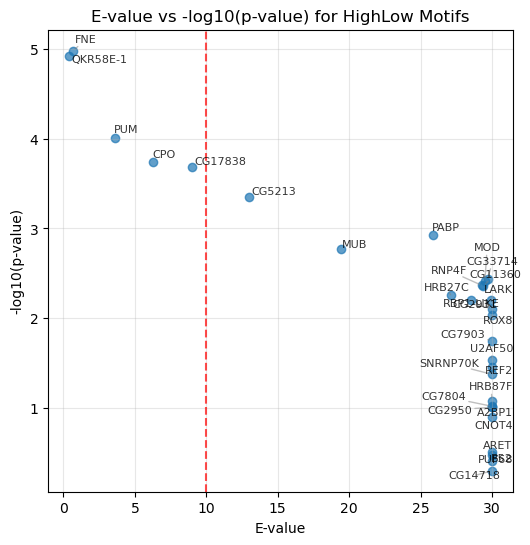

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text

# Create scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(highLow['E-value'],-np.log10(highLow['p-value']),  alpha=0.7)
plt.axvline(x=10, color='red', linestyle='--', alpha=0.7, label='E-value = 10')

# Add motif labels with adjustText to prevent overlaps

texts = []
for i, row in highLow.iterrows():
    if pd.notna(row['motif_alt_ID']):
        text = plt.annotate(row['motif_alt_ID'], 
                    (row['E-value'], -np.log10(row['p-value'])),
                    fontsize=8, alpha=0.8)
        texts.append(text)

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5))

plt.xlabel('E-value')
plt.ylabel('-log10(p-value)')
plt.title('E-value vs -log10(p-value) for HighLow Motifs')
plt.grid(True, alpha=0.3)
plt.show()

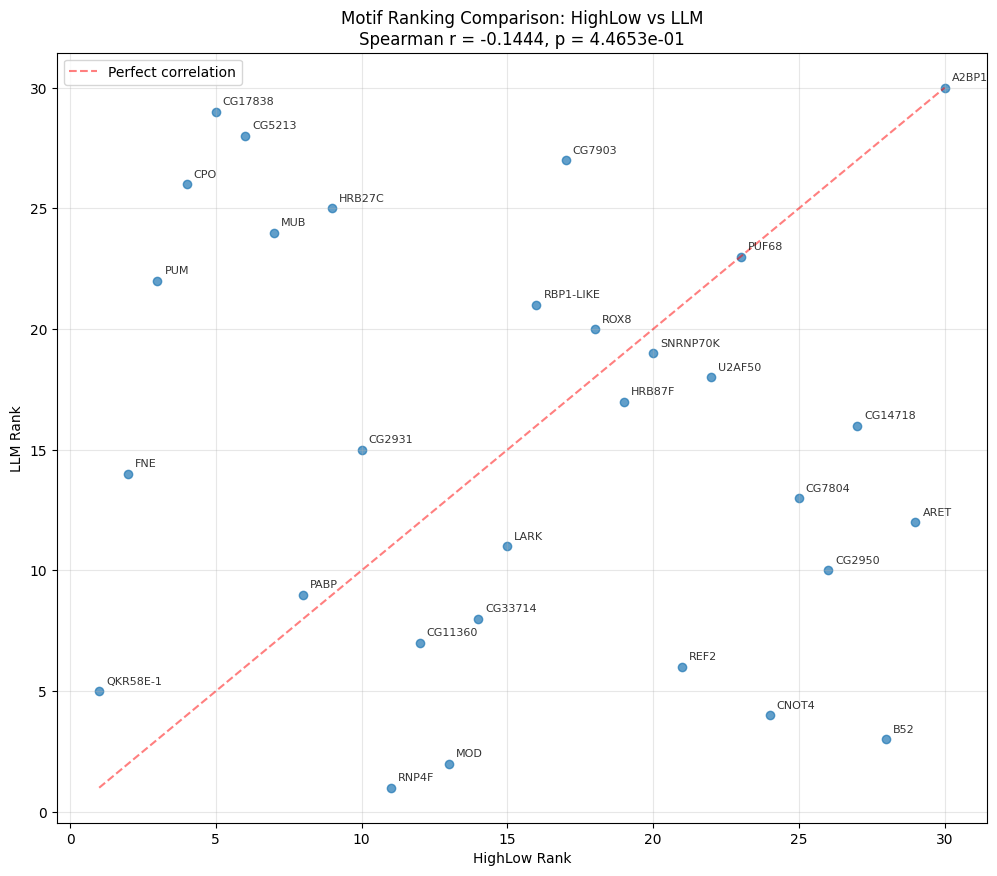

Spearman correlation: -0.1444
P-value: 4.4653e-01
Number of common motifs: 30


In [5]:
import matplotlib.pyplot as plt

# Create rank columns for both dataframes
highLow_ranked = highLow.copy()
llm_ranked = llm.copy()

# Remove rows with NaN values in motif_alt_ID
highLow_ranked = highLow_ranked.dropna(subset=['motif_alt_ID'])
llm_ranked = llm_ranked.dropna(subset=['motif_alt_ID'])

# Create rank columns (1-indexed)
highLow_ranked['rank_num'] = range(1, len(highLow_ranked) + 1)
llm_ranked['rank_num'] = range(1, len(llm_ranked) + 1)

# Merge on motif_alt_ID to get common motifs
merged = pd.merge(highLow_ranked[['motif_alt_ID', 'rank_num']], 
                  llm_ranked[['motif_alt_ID', 'rank_num']], 
                  on='motif_alt_ID', 
                  suffixes=('_highLow', '_llm'))

from scipy.stats import spearmanr

# Calculate Spearman correlation
corr, p_value = spearmanr(merged['rank_num_highLow'], merged['rank_num_llm'])

# Create scatter plot
plt.figure(figsize=(12, 10))
plt.scatter(merged['rank_num_highLow'], merged['rank_num_llm'], alpha=0.7)

# Add motif_alt_ID labels to each point
for i, row in merged.iterrows():
    plt.annotate(row['motif_alt_ID'], 
                (row['rank_num_highLow'], row['rank_num_llm']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, alpha=0.8)

plt.xlabel('HighLow Rank')
plt.ylabel('LLM Rank')
plt.title(f'Motif Ranking Comparison: HighLow vs LLM\nSpearman r = {corr:.4f}, p = {p_value:.4e}')

# Add diagonal line for reference
max_rank = max(merged['rank_num_highLow'].max(), merged['rank_num_llm'].max())
plt.plot([1, max_rank], [1, max_rank], 'r--', alpha=0.5, label='Perfect correlation')

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print correlation results
print(f"Spearman correlation: {corr:.4f}")
print(f"P-value: {p_value:.4e}")
print(f"Number of common motifs: {len(merged)}")


In [6]:
#linearRegressionRank = ['U2AF50', 'FNE', 'CG5213', 'ARET', 'CG17838', 'A2BP1', 'RNP4F', 'CG7903', 'B52', 'PUF68', 'RBP1-LIKE', 'CG2950', 'CPO', 'QKR58E-1', 'CG2931', 'CG14718', 'ROX8', 'MUB', 'SNRNP70K', 'HRB27C', 'PUM', 'CG7804', 'HRB87F', 'CG33714', 'CNOT4', 'LARK', 'MOD', 'CG11360', 'REF2', 'PABP']
linearRegressionRank = ['RNP4F', 'B52', 'CG2950', 'HRB27C', 'HRB87F', 'CNOT4', 'MOD', 'CG11360', 'PABP', 'REF2', 'LARK', 'CG33714', 'CG7804', 'PUM', 'SNRNP70K', 'MUB', 'ROX8', 'CG14718', 'CG2931', 'QKR58E-1', 'CPO', 'RBP1-LIKE', 'PUF68', 'CG7903', 'A2BP1', 'CG17838', 'ARET', 'CG5213', 'FNE', 'U2AF50']
#linearRegressionRank = ['CG7804', 'SF2', 'RNP4F', 'B52', 'FMR1', 'EIF-2ALPHA', 'CNOT4', 'RBP1', 'MSI', 'HRB27C', 'HOW', 'BRU-3', 'ARET', 'CG2950', 'PABP', 'CG11360', 'SRP54', 'CG14718', 'SNRNP70K', 'TRA2', 'SM', 'QKR58E-1', 'ORB2', 'REF2', 'FNE', 'MOD', 'CG2931', 'CPO', 'MUB', 'ROX8', 'CG5213', 'RSF1', 'PUF68', 'SHEP', 'LARK', 'HRB98DE', 'CG7903', 'RBP1-LIKE', 'CG33714', 'PAPI', 'SF1', 'CG17838', 'U2AF50', 'RIN', 'A2BP1', 'PUM', 'SXL', 'HRB87F', 'SNF', 'RBP9', 'ELAV']

HighLow vs Linear Regression:
Spearman correlation: -0.1257, p-value: 5.0807e-01
Number of common motifs: 30

LLM vs Linear Regression:
Spearman correlation: 0.6089, p-value: 3.5599e-04
Number of common motifs: 30


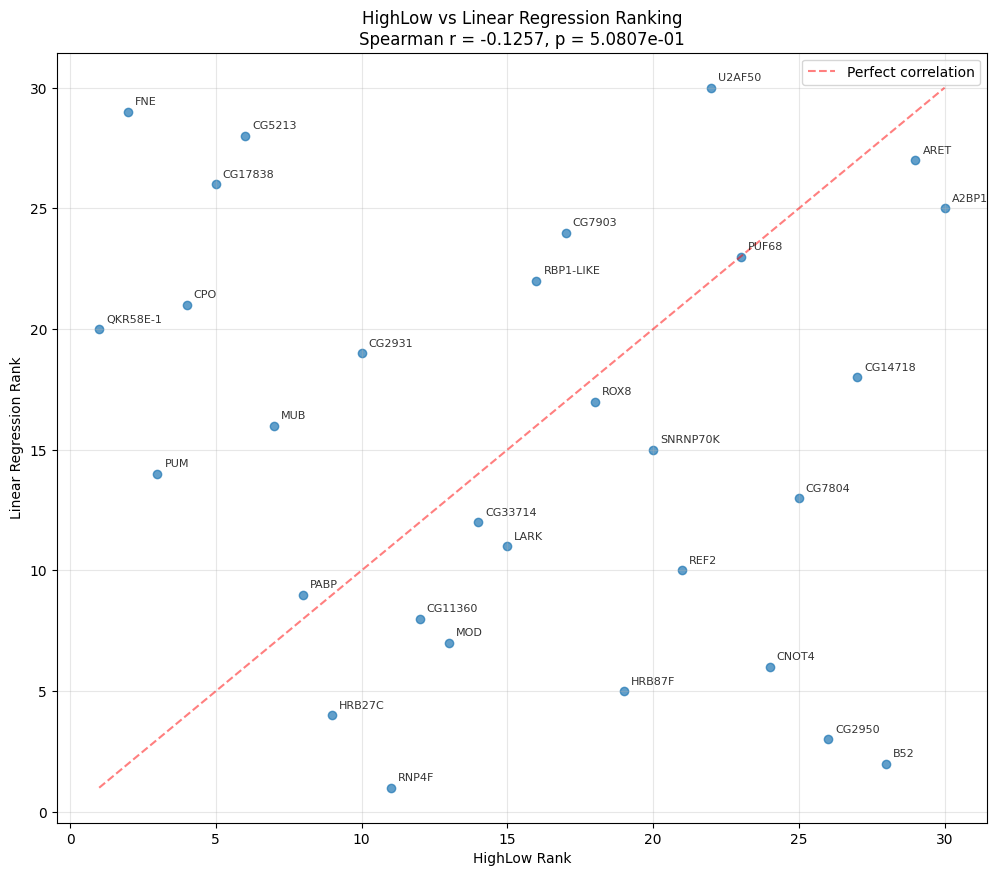

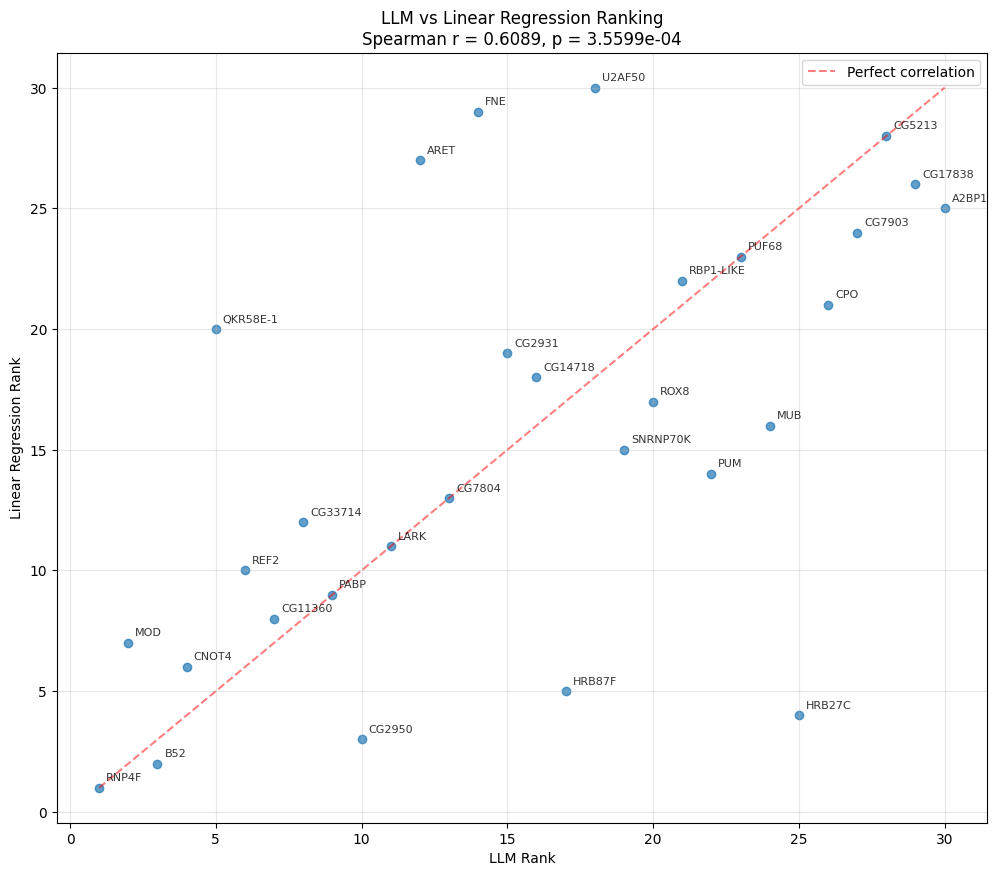

In [7]:
from scipy.stats import spearmanr
import numpy as np

# Create dataframes with linear regression ranks
linearRegressionRank_df = pd.DataFrame({
    'motif_alt_ID': linearRegressionRank,
    'rank_num': range(1, len(linearRegressionRank) + 1)
})

# Merge highLow with linear regression ranks
merged_highLow_lr = pd.merge(highLow_ranked[['motif_alt_ID', 'rank_num']], 
                            linearRegressionRank_df[['motif_alt_ID', 'rank_num']], 
                            on='motif_alt_ID', 
                            suffixes=('_highLow', '_lr'))

# Merge llm with linear regression ranks
merged_llm_lr = pd.merge(llm_ranked[['motif_alt_ID', 'rank_num']], 
                        linearRegressionRank_df[['motif_alt_ID', 'rank_num']], 
                        on='motif_alt_ID', 
                        suffixes=('_llm', '_lr'))

# Calculate Spearman correlations
corr_highLow_lr, p_val_highLow_lr = spearmanr(merged_highLow_lr['rank_num_highLow'], 
                                              merged_highLow_lr['rank_num_lr'])
corr_llm_lr, p_val_llm_lr = spearmanr(merged_llm_lr['rank_num_llm'], 
                                      merged_llm_lr['rank_num_lr'])

print(f"HighLow vs Linear Regression:")
print(f"Spearman correlation: {corr_highLow_lr:.4f}, p-value: {p_val_highLow_lr:.4e}")
print(f"Number of common motifs: {len(merged_highLow_lr)}")

print(f"\nLLM vs Linear Regression:")
print(f"Spearman correlation: {corr_llm_lr:.4f}, p-value: {p_val_llm_lr:.4e}")
print(f"Number of common motifs: {len(merged_llm_lr)}")

# Plot HighLow vs Linear Regression
plt.figure(figsize=(12, 10))
plt.scatter(merged_highLow_lr['rank_num_highLow'], merged_highLow_lr['rank_num_lr'], alpha=0.7)

for i, row in merged_highLow_lr.iterrows():
    plt.annotate(row['motif_alt_ID'], 
                (row['rank_num_highLow'], row['rank_num_lr']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, alpha=0.8)

plt.xlabel('HighLow Rank')
plt.ylabel('Linear Regression Rank')
plt.title(f'HighLow vs Linear Regression Ranking\nSpearman r = {corr_highLow_lr:.4f}, p = {p_val_highLow_lr:.4e}')

max_rank = max(merged_highLow_lr['rank_num_highLow'].max(), merged_highLow_lr['rank_num_lr'].max())
plt.plot([1, max_rank], [1, max_rank], 'r--', alpha=0.5, label='Perfect correlation')

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot LLM vs Linear Regression
plt.figure(figsize=(12, 10))
plt.scatter(merged_llm_lr['rank_num_llm'], merged_llm_lr['rank_num_lr'], alpha=0.7)

for i, row in merged_llm_lr.iterrows():
    plt.annotate(row['motif_alt_ID'], 
                (row['rank_num_llm'], row['rank_num_lr']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, alpha=0.8)

plt.xlabel('LLM Rank')
plt.ylabel('Linear Regression Rank')
plt.title(f'LLM vs Linear Regression Ranking\nSpearman r = {corr_llm_lr:.4f}, p = {p_val_llm_lr:.4e}')

max_rank = max(merged_llm_lr['rank_num_llm'].max(), merged_llm_lr['rank_num_lr'].max())
plt.plot([1, max_rank], [1, max_rank], 'r--', alpha=0.5, label='Perfect correlation')

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


HIGH_ALL vs Linear Regression:
Spearman correlation: -0.1528, p-value: 4.2007e-01
Number of common motifs: 30


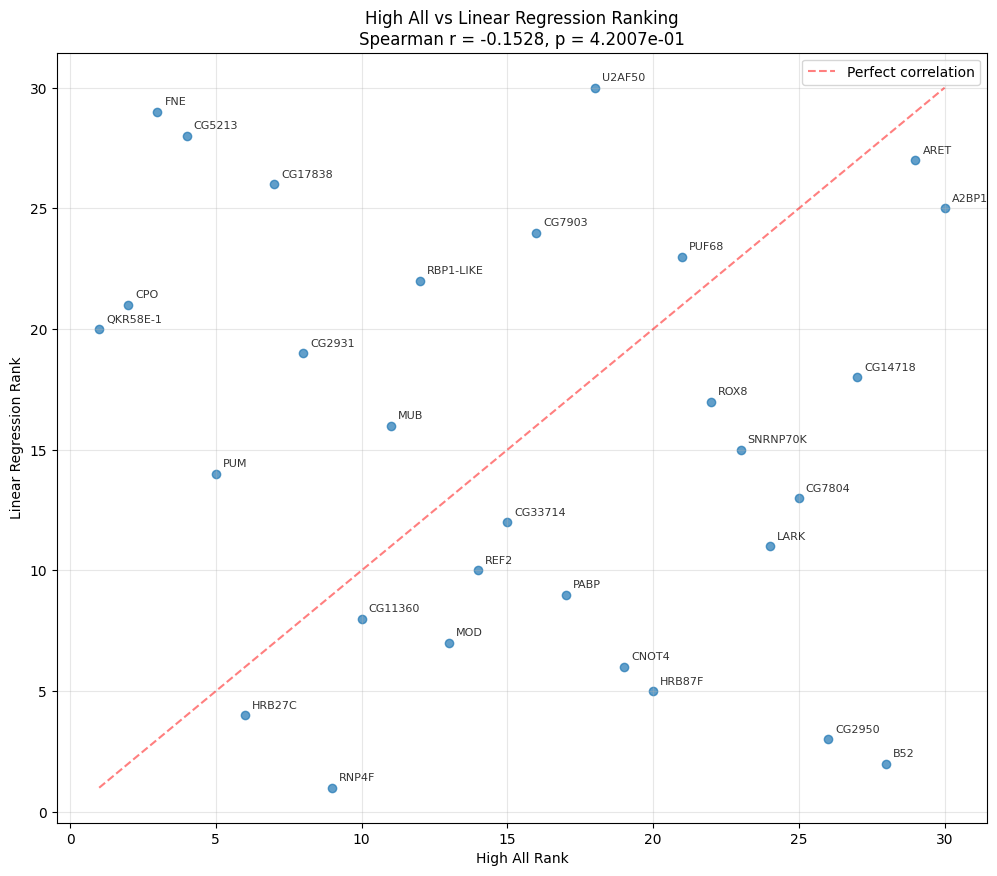


LOW_TRAIN vs Linear Regression:
Spearman correlation: 0.0220, p-value: 9.0803e-01
Number of common motifs: 30


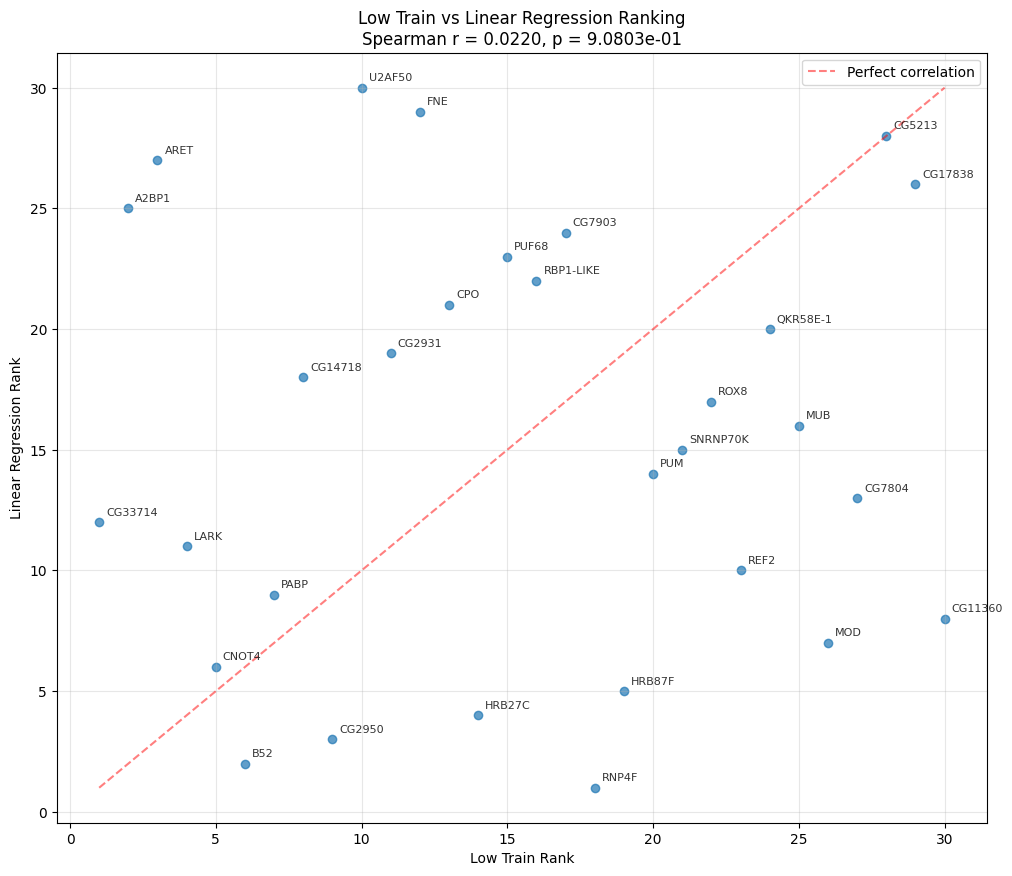


LOW_ALL vs Linear Regression:
Spearman correlation: 0.0652, p-value: 7.3219e-01
Number of common motifs: 30


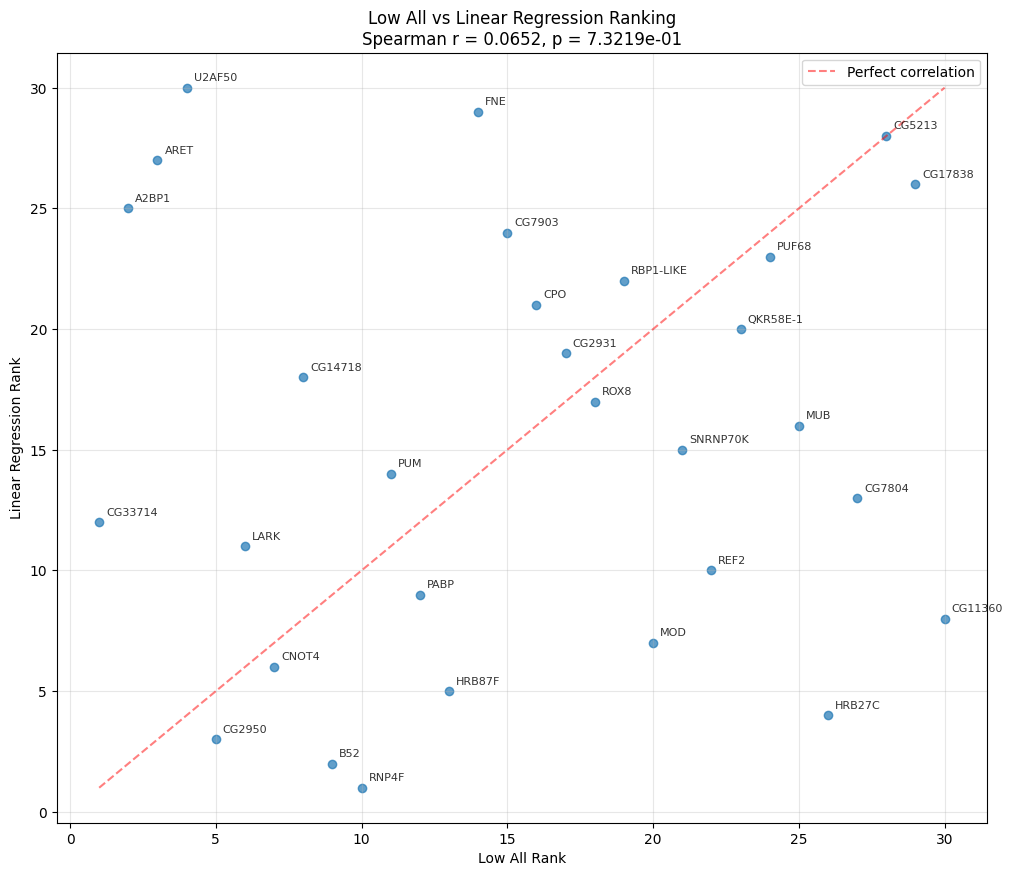

In [11]:
#
high_all = pd.read_csv('output/splitDecay/high/all_ame_output/ame.tsv', sep='\t')
low_train = pd.read_csv('output/splitDecay/low/train_ame_output/ame.tsv', sep='\t')
low_all = pd.read_csv('output/splitDecay/low/all_ame_output/ame.tsv', sep='\t')

# Remove duplicates and NaN values, create ranks for each dataset
datasets = {
    'high_all': high_all,
    'low_train': low_train,
    'low_all': low_all
}

ranked_datasets = {}
for name, df in datasets.items():
    # Remove duplicates and NaN values
    df_clean = df[~df[['motif_alt_ID']].duplicated()].dropna(subset=['motif_alt_ID'])
    # Create rank column
    df_clean['rank_num'] = range(1, len(df_clean) + 1)
    ranked_datasets[name] = df_clean

# Run correlation analyses for each dataset against linear regression ranks
for name, df_ranked in ranked_datasets.items():
    print(f"\n{name.upper()} vs Linear Regression:")
    
    # Merge with linear regression ranks
    merged_lr = pd.merge(df_ranked[['motif_alt_ID', 'rank_num']], 
                        linearRegressionRank_df[['motif_alt_ID', 'rank_num']], 
                        on='motif_alt_ID', 
                        suffixes=(f'_{name}', '_lr'))
    
    # Calculate Spearman correlation
    corr_lr, p_val_lr = spearmanr(merged_lr[f'rank_num_{name}'], merged_lr['rank_num_lr'])
    
    print(f"Spearman correlation: {corr_lr:.4f}, p-value: {p_val_lr:.4e}")
    print(f"Number of common motifs: {len(merged_lr)}")
    
    # Create scatter plot
    plt.figure(figsize=(12, 10))
    plt.scatter(merged_lr[f'rank_num_{name}'], merged_lr['rank_num_lr'], alpha=0.7)
    
    # Add motif labels
    for i, row in merged_lr.iterrows():
        plt.annotate(row['motif_alt_ID'], 
                    (row[f'rank_num_{name}'], row['rank_num_lr']),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=8, alpha=0.8)
    
    plt.xlabel(f'{name.replace("_", " ").title()} Rank')
    plt.ylabel('Linear Regression Rank')
    plt.title(f'{name.replace("_", " ").title()} vs Linear Regression Ranking\nSpearman r = {corr_lr:.4f}, p = {p_val_lr:.4e}')
    
    # Add diagonal reference line
    max_rank = max(merged_lr[f'rank_num_{name}'].max(), merged_lr['rank_num_lr'].max())
    plt.plot([1, max_rank], [1, max_rank], 'r--', alpha=0.5, label='Perfect correlation')
    
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


HIGH_ALL vs LLM:
Spearman correlation: -0.1293, p-value: 4.9604e-01
Number of common motifs: 30


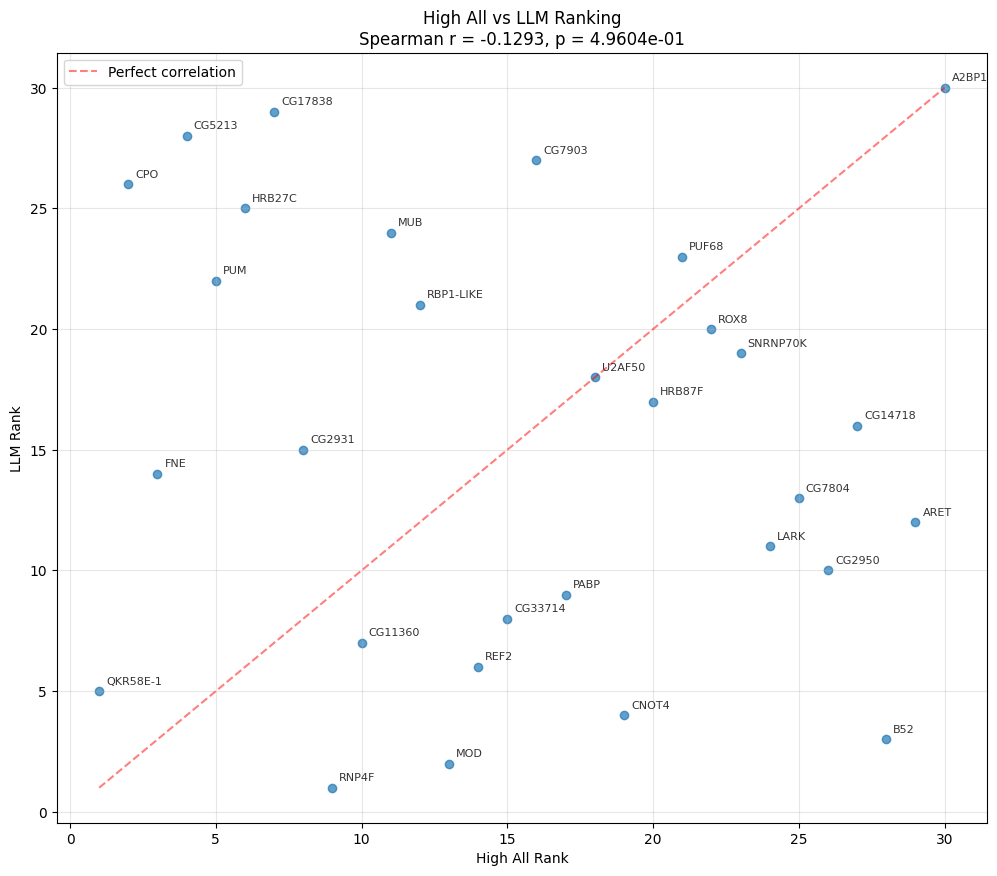


LOW_TRAIN vs LLM:
Spearman correlation: 0.1408, p-value: 4.5793e-01
Number of common motifs: 30


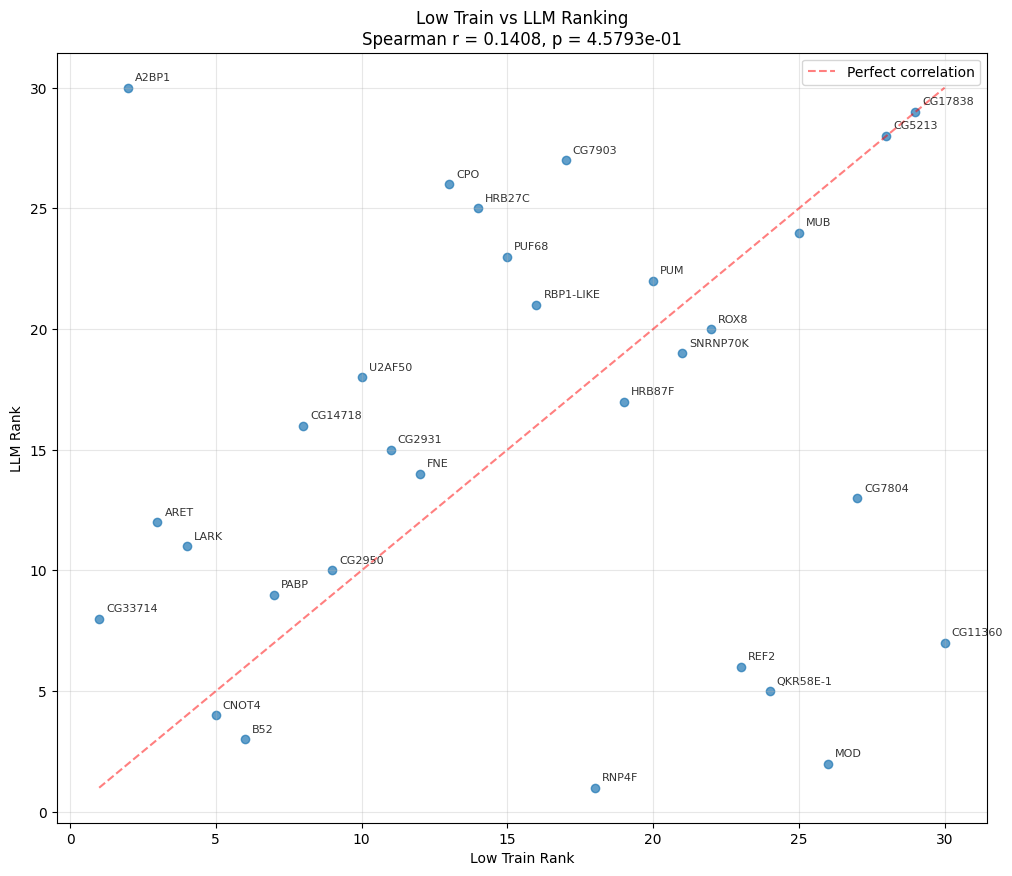


LOW_ALL vs LLM:
Spearman correlation: 0.2463, p-value: 1.8956e-01
Number of common motifs: 30


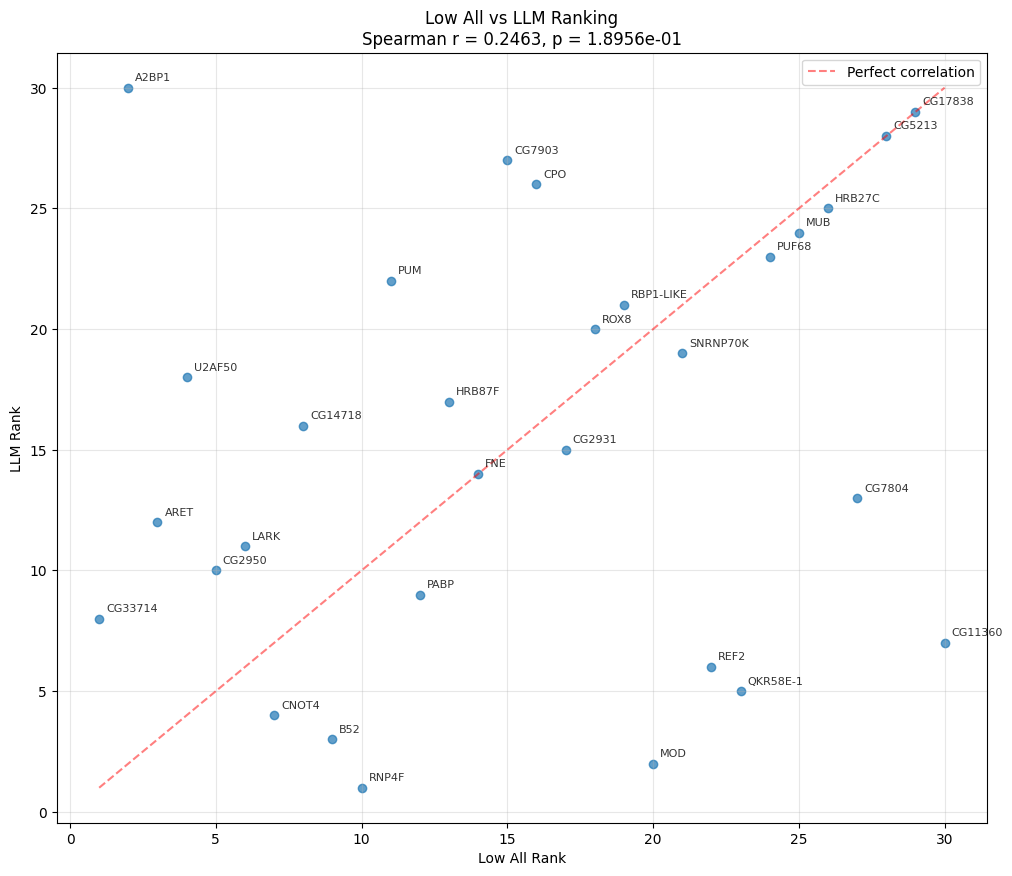

In [12]:
# Additional comparisons with LLM values for the three new datasets
for name, df_ranked in ranked_datasets.items():
    print(f"\n{name.upper()} vs LLM:")
    
    # Merge with LLM ranks
    merged_llm = pd.merge(df_ranked[['motif_alt_ID', 'rank_num']], 
                         llm_ranked[['motif_alt_ID', 'rank_num']], 
                         on='motif_alt_ID', 
                         suffixes=(f'_{name}', '_llm'))
    
    # Calculate Spearman correlation
    corr_llm, p_val_llm = spearmanr(merged_llm[f'rank_num_{name}'], merged_llm['rank_num_llm'])
    
    print(f"Spearman correlation: {corr_llm:.4f}, p-value: {p_val_llm:.4e}")
    print(f"Number of common motifs: {len(merged_llm)}")
    
    # Create scatter plot
    plt.figure(figsize=(12, 10))
    plt.scatter(merged_llm[f'rank_num_{name}'], merged_llm['rank_num_llm'], alpha=0.7)
    
    # Add motif labels
    for i, row in merged_llm.iterrows():
        plt.annotate(row['motif_alt_ID'], 
                    (row[f'rank_num_{name}'], row['rank_num_llm']),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=8, alpha=0.8)
    
    plt.xlabel(f'{name.replace("_", " ").title()} Rank')
    plt.ylabel('LLM Rank')
    plt.title(f'{name.replace("_", " ").title()} vs LLM Ranking\nSpearman r = {corr_llm:.4f}, p = {p_val_llm:.4e}')
    
    # Add diagonal reference line
    max_rank = max(merged_llm[f'rank_num_{name}'].max(), merged_llm['rank_num_llm'].max())
    plt.plot([1, max_rank], [1, max_rank], 'r--', alpha=0.5, label='Perfect correlation')
    
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
